# Paso 4. Análisis exploratorio de datos (Python)

Cargamos y preparamos los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos los datasets
companies_df = pd.read_csv('/datasets/project_sql_result_01.csv')
neighborhoods_df = pd.read_csv('/datasets/project_sql_result_04.csv')

# Vemos los tipos de datos y valores nulos que se encuentran en los datasets.
print(companies_df.info())
print(neighborhoods_df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [2]:
print(companies_df.head())
print(neighborhoods_df.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


Identificamos los 10 principales barrios en términos de finalización del recorrido


In [3]:
top_neighborhoods = neighborhoods_df.sort_values('average_trips', ascending=False).head(10)
print(top_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Visualizamos los datos

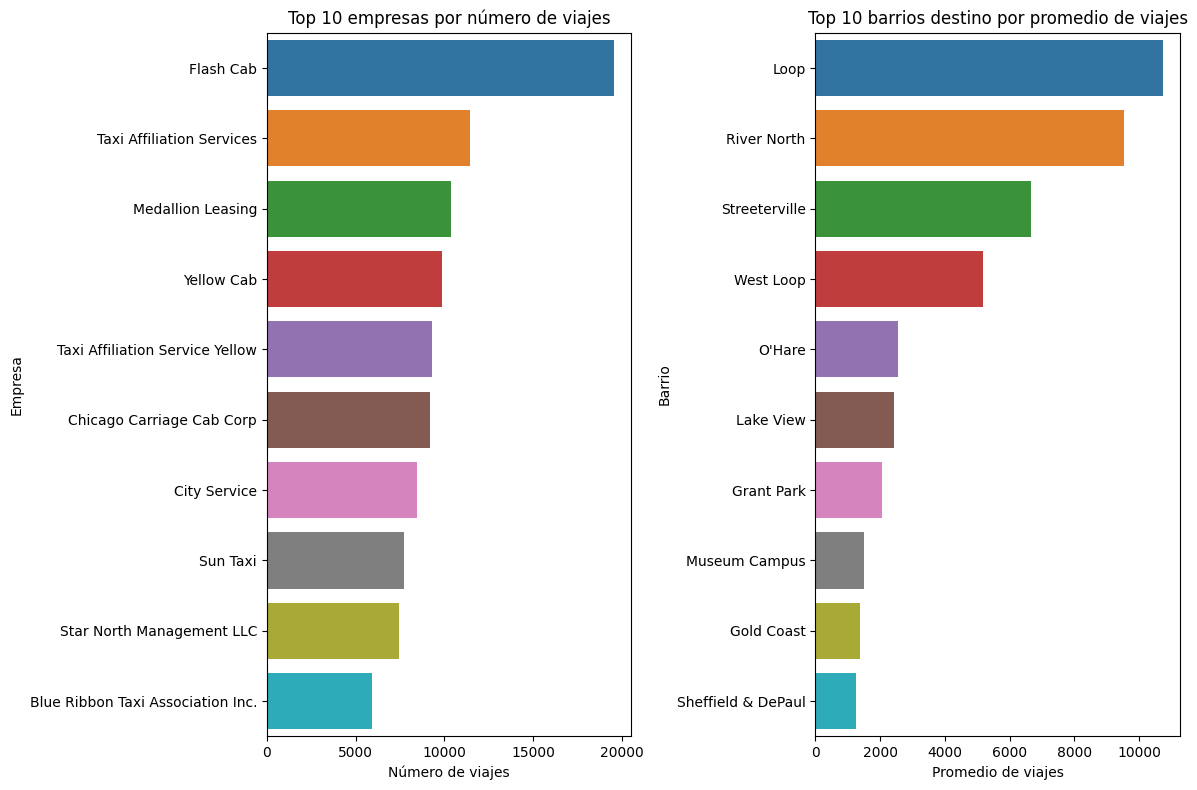

In [15]:
plt.figure(figsize=(12, 8))

# Gráfico de empresas 
plt.subplot(1, 2, 1)
sns.barplot(x='trips_amount', y='company_name', 
            data=companies_df.sort_values('trips_amount', ascending=False).head(10))
plt.title('Top 10 empresas por número de viajes')
plt.xlabel('Número de viajes')
plt.ylabel('Empresa')

# Gráfico de barrios
plt.subplot(1, 2, 2)
sns.barplot(x='average_trips', y='dropoff_location_name', 
            data=top_neighborhoods)
plt.title('Top 10 barrios destino por promedio de viajes')
plt.xlabel('Promedio de viajes')
plt.ylabel('Barrio')

plt.tight_layout()
plt.show()

### Conclusiones 
En conclusion, podemos ver que las empresas Flash Cab y Taxi Affiliation Services son claramente las empresas dominantes en numero de viajes.Viendo una diferencia entre las 2 primeras empresas y el resto,mas por parte de la empresa Flash Cab.
Por lo que el mercado está altamente concentrado en pocas empresas

Mientras que por parte de los barrios ,los barrios destino con mayor promedio de viajes fueron Loop, River North y Streeterville,esto puede ser principalmente a que son barrios que coinciden con zonas comerciales y turísticas de Chicago.Por lo que podemos decir que ciertos barrios destinatarios concentran la mayoría de los viajes.

# Paso 5. Prueba de hipótesis (Python)

Cargamos y preparamos los datos

In [18]:
trips_df = pd.read_csv('/datasets/project_sql_result_07.csv')

print(trips_df.info())
print(trips_df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
5  2017-11-11 04:00:00               Good            1320.0
6  2017-11-04 16:00:00                Bad            2969.0
7  2017-11-18 11:00:00               Good            2280.0
8  2017-11-11 14:00:00               Good          

In [17]:
# Convertimos tipos de datos
trips_df['start_ts'] = pd.to_datetime(trips_df['start_ts'])
trips_df['duration_seconds'] = trips_df['duration_seconds'].astype('int')

print(trips_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 25.2+ KB
None


In [19]:
# Dividimos en dos grupos: condiciones buenas vs malas
good_weather = trips_df[trips_df['weather_conditions'] == 'Good']['duration_seconds']
bad_weather = trips_df[trips_df['weather_conditions'] == 'Bad']['duration_seconds']

### Formulamos nuestra hipótesis:
Hipótesis nula (H₀): No hay diferencia en la duración promedio de los viajes entre días lluviosos y no lluviosos

Hipótesis alternativa (H₁): Existe diferencia significativa en la duración promedio

In [20]:
from scipy import stats

alpha = 0.05

results = stats.ttest_ind(good_weather, bad_weather)
print('valor p: ', results.pvalue) 

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula - hay diferencia significativa")
else:
    print("No podemos rechazar la hipótesis nula - no hay diferencia significativa")

valor p:  6.517970327099473e-12
Rechazamos la hipótesis nula - hay diferencia significativa


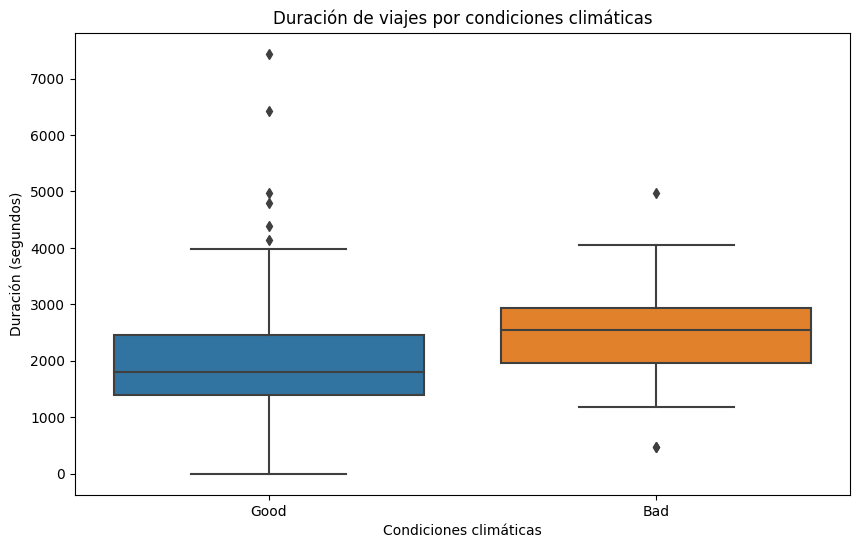

In [21]:
# Graficamos para tener una mejor visualización
plt.figure(figsize=(10, 6))
sns.boxplot(x='weather_conditions', y='duration_seconds', data=trips_df)
plt.title('Duración de viajes por condiciones climáticas')
plt.xlabel('Condiciones climáticas')
plt.ylabel('Duración (segundos)')
plt.show()


### Explicaciones de la prueba de hipótesis.
Basado en el valor p obtenido y comparandolo con alpha (0.05), pudimos determinar si hay diferencia significativa entrelas condiciones buena y mala de clima.
Planteando las hipótesis de manera que la hipotesis nula nos iba a decir si no habia diferencia en la duración promedio de los viajes entre días lluviosos y no lluviosos y la hipótesis alternativa nos iba a decir lo contrario.
Utilize la Prueba Estadística (T-test Independiente) debido a la naturaleza de los datos, ya que tenemos dos grupos independientes (clima "Good" y "Bad") con una variable continua (duración en segundos).Siendo una prueba que nos responde directamente a la pregunta de investigación,proporcionandonos resultados concluyentes.

Resultado: Ya que si se rechazo la hipótesis nula, podemos llegar a la conclusion que gracias a el mal clima,que se puede traducir en dias lluviosos,eso provoca que los viajes sean más largos ,gracias a posiblemente el tráfico que provoca que se vaya más lento.

